In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'income_tax_collection',
    persist_directory = './income_tax_collection'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [3]:
from typing import NotRequired
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: NotRequired[ List[Document]]
    answer: NotRequired[str]

graph_builder = StateGraph(AgentState)

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

In [5]:
generate_prompt = ChatPromptTemplate.from_template(
    """You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use three sentences maximum and keep the answer concise.
답변은 한국어로 해주세요

Question: {question}

Context: {context}

Answer:"""
)

relevance_prompt = ChatPromptTemplate.from_template(
      """당신은 검색된 문서와 사용자 질문의 관련성을 평가하는 채점자입니다.

  검색된 문서에 사용자 질문과 관련된 키워드나 의미가 포함되어 있다면 관련 있다고 판단하세요.
  엄격하게 평가할 필요는 없으며, 명백히 관련 없는 문서를 걸러내는 것이 목적입니다.

  관련성이 있으면 1, 관련성이 없으면 0으로 평가하세요.

  Question: {question}

  Documents: {documents}

  Score:"""
)

# 사전 정의: 특정 표현을 다른 표현으로 변환하기 위한 사전입니다.
dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(f"""
사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요
사전: {dictionary}
질문: {{query}}
""")





In [6]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {'context':docs}

In [7]:
def generate(state:AgentState):
    query = state['query']
    context = state['context']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question':query,'context':context})
    return {'answer':response}

In [8]:
from typing import Literal
from pydantic import BaseModel, Field


class RelevanceGrade(BaseModel):
    score: int = Field(description="문서가 질문과 관련 있으면 1, 관련 없으면 0")
    explanation: str = Field(description="관련성을 판단한 이유")


def check_doc_relevance(
    state: AgentState,
) -> Literal["generate", "rewrite"]:
    query = state["query"]
    context = state["context"]

    relevance_llm = llm.with_structured_output(RelevanceGrade)
    relevance_doc_chain = relevance_prompt | relevance_llm
    response = relevance_doc_chain.invoke({
        "question": query,
        "documents": context,
    })

    if response.score == 1:
        return "generate"

    return "rewrite"


In [9]:
from langchain_core.output_parsers import StrOutputParser

def rewrite(state: AgentState):
    query = state["query"]
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({"query": query})
    return {"query": response}

In [10]:
graph_builder.add_node('retrieve',retrieve)
# graph_builder.add_node('check_doc_relevance',check_doc_relevance)
graph_builder.add_node('generate',generate)
graph_builder.add_node('rewrite',rewrite)

In [11]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges('retrieve',check_doc_relevance)
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)

In [12]:
graph = graph_builder.compile()

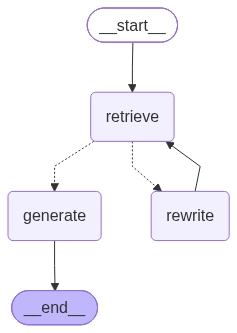

In [13]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
initial_state = {'query':'연봉 5천만원 세금'}
graph.invoke(initial_state)

{'query': '거주자의 연봉 5천만 원에 대한 세금은 어떻게 되나요?',
 'context': [Document(id='6ce2a828-dd6b-4b46-8e68-ce76a2e66295', metadata={'source': '../docs/income_tax.txt'}, page_content='5년 이하: 30만원 → 납입연수\n5년 초과 10년 이하: 150만원 + 50만원 × (납입연수 - 5년)\n10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지급받는 경우 세액의 계산 방법 등 필요한 사항은 대통령령으로 정한다. \n<대통령 2014. 12. 23.>\n<전문개정 2009. 12. 31.>\n제64조(부동산매매업자에 대한 세액 계산의 특례)\n1) 대통령령으로 정하는 부동산매매업(이하 “부동산매매업”이라 한다)을 영위하는 거주자가 이하 “부동산매매업자”라 한다)로서 종합소득세법에 제104조제1항제1호(본항을 포함한다) 및 제103조 또는 같은 조 제7항 각 호의 어느 하나에 해당하는 자산의 매매자익(이하 “주택등매매차익”이라 한다)이 있는 자의 종합소득 산출세액은 다음 각 호의 세액 중 많은 것으로 한다. \n<개정 2014. 12. 23., 2017. 12. 19., 2020. 12. 29.>\n1. 종합소득 산출세액\n\n다음 각 목에 따른 세액의 합계액\n  가. 주택등매매차익에 따른 세율을 적용하여 산출한 세액의 합계액\n  나. 종합소득세법 제55조에 따라 주택등매매차익에 대한 개별세액을 공제한 금액을 과세표준으로 하고 이에 제55조에 따른 세율을 적용하여 산출세액'),
  Document(id='06dab60a-611a-4a4f-9391-9d0dccd90e5d', metadata={'source': '../docs/income_tax.txt'}, page_content='② 제70조제1항, 